In [1]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

from pynq import Overlay, MMIO
from pynq.lib import AxiGPIO

In [2]:
def camera_init():
    camera = cv2.VideoCapture(0, cv2.CAP_V4L2)
    camera.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
    camera.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    camera.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    for _ in range(15):
        ret, frame = camera.read()
        if frame is not None and frame.max() > 0:
            break
        time.sleep(0.1)
    print("Camera ready:", ret and frame.max() > 0)
    return camera

def get_cam_image(camera, display=True):
    """Flush stale frames and return a fresh BGR frame."""
    for _ in range(10):
        camera.grab()
    ret, frame = camera.read()
    if not ret or frame.max() <= 2:
        raise RuntimeError("Failed to capture a valid frame.")
    if display:
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title('USB Camera Capture')
        plt.axis('off')
        plt.show()
    return frame

def deinit_camera(camera):
    camera.release()
    time.sleep(2)
    print("Camera released.")

In [3]:
BITSTREAM    = "/home/xilinx/jupyter_notebooks/Startracker_Project/startracker.bit"    # .hwh must sit alongside this
CNN_IP_NAME  = "star_tracker_cnn_0"  # verify with: print(list(ol.ip_dict.keys()))
BRAM_IP_NAME = "axi_bram_ctrl_0"     # verify with ip_dict
GPIO_IP_NAME = "axi_gpio_0"          # verify with ip_dict

# Dimensions must match the synthesized bitstream (8 KB BRAM = 2048 x uint32 = 64x32).
# Update to 160x120 only after re-synthesizing with the updated star_tracker_weights.h.
MODEL_W = 64
MODEL_H = 32

# AXI-Lite register offsets (from Vitis HLS synthesis report)
REG_CTRL       = 0x00
REG_PRED_CLASS = 0x1C
AP_START = 1 << 0
AP_DONE  = 1 << 1
AP_IDLE  = 1 << 2

# Arduino header bit positions for each class (matches arduino_led.xdc)
# AR9=Up, AR7=Down, AR13=Left, AR11=Right, AR5=Forward, AR3=Backward
CLASS_NAMES   = ["Up", "Down", "Left", "Right", "Forward", "Backward"]
CLASS_TO_BIT  = {0: 9, 1: 7, 2: 13, 3: 11, 4: 5, 5: 3}
GPIO_MASK     = 0x3FFF   # 14-bit mask covering Arduino_IO[0:13]

In [4]:
ol = Overlay(BITSTREAM)
ol?


In [5]:
# CNN accelerator — PYNQ exposes it as DefaultIP; use .read()/.write() for AXI-Lite registers
cnn = ol.star_tracker_cnn_0
assert cnn.read(REG_CTRL) & AP_IDLE, \
    "CNN IP not idle — check CNN_IP_NAME or re-program bitstream"
print(f"CNN IP ready  (AP_IDLE=1)")

# BRAM — axi_bram_ctrl_0 (Single Port, BRAM_PORTA) and the CNN input_image (BRAM_PORTB)
# share one dual-port blk_mem_gen_0.  Writes here go directly to the CNN's input.
bram_base = ol.mem_dict[BRAM_IP_NAME]['base_address']
bram_size = ol.mem_dict[BRAM_IP_NAME]['addr_range']
bram = MMIO(bram_base, bram_size)
print(f"BRAM mapped   base=0x{bram_base:08X}  size={bram_size} B")

# AXI GPIO — the overlay already instantiated the AxiGPIO driver; access it directly.
gpio = ol.axi_gpio_0.channel1
gpio.setdirection('out')
gpio.write(0x0000, GPIO_MASK)  # all LEDs off
print("LED GPIO ready (all off)")

CNN IP ready  (AP_IDLE=1)
BRAM mapped   base=0x40000000  size=8192 B
LED GPIO ready (all off)


In [6]:
def preprocess(frame):
    """BGR 640x480 -> float32 grayscale 160x120, max-normalized, scaled to uint8.

    Two fixes for "always predicts UP":
      1. Dimensions were 64x32 instead of 160x120 (ST_INPUT_WIDTH/ST_INPUT_HEIGHT).
         Only 2048 pixels were written to BRAM but the FPGA reads 19200; the
         remaining pixels were zero, making the network see a blank image.
      2. Raw pixel values were passed without normalization. Training uses
         max-normalize (img / img.max()), so the brightest star always lands
         at 1.0.  Skipping this shifts the input distribution and biases the
         classifier toward class 0 (Up).
    """
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
    small = cv2.resize(gray, (MODEL_W, MODEL_H), interpolation=cv2.INTER_AREA)
    max_val = small.max()
    if max_val > 1e-6:
        small = small / max_val   # max-normalize: matches train.py
    return (small * 255).astype(np.uint8)

def write_bram(small):
    """Write MODEL_W x MODEL_H grayscale image into BRAM (one pixel per 32-bit word)."""
    bram.array[0 : MODEL_W * MODEL_H] = small.flatten().astype(np.uint32)

def run_inference():
    """Pulse ap_start, wait for ap_done, return predicted class int."""
    start = time.perf_counter()
    cnn.write(REG_CTRL, AP_START)
    while not (cnn.read(REG_CTRL) & AP_DONE):
        pass
    
    end = time.perf_counter()
    return int(cnn.read(REG_PRED_CLASS))

def set_led(cls):
    """Light exactly the LED for cls, extinguish all others."""
    if 0 <= cls < len(CLASS_NAMES):
        bitmask = 1 << CLASS_TO_BIT[cls]
    else:
        bitmask = 0   # all off for invalid class
    gpio.write(bitmask, GPIO_MASK)

def all_leds_off():
    gpio.write(0x0000, GPIO_MASK)

print("Helper functions defined.")

Helper functions defined.


In [7]:
# If this cell fails on first run, execute it again — the camera sometimes
# needs a second attempt to initialise (see camera_driver.ipynb)
camera = camera_init()

Camera ready: True


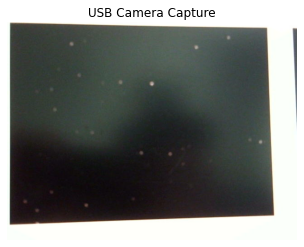

Predicted class: 0  →  Up


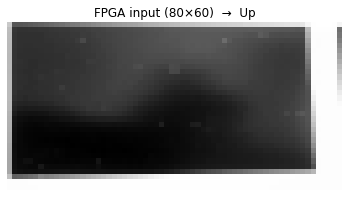

In [17]:
frame = get_cam_image(camera, display=True)
small = preprocess(frame)

write_bram(small)
cls = run_inference()
set_led(cls)

print(f"Predicted class: {cls}  →  {CLASS_NAMES[cls]}")

# Show the preprocessed 80×60 input that was sent to the FPGA
plt.imshow(small, cmap='gray')
plt.title(f'FPGA input (80×60)  →  {CLASS_NAMES[cls]}')
plt.axis('off')
plt.show()

In [16]:
stop_btn = widgets.Button(description="Stop", button_style="danger")
out      = widgets.Output()
running  = {"v": True}

def on_stop(_):
    running["v"] = False

stop_btn.on_click(on_stop)
display(stop_btn, out)

frame_count = 0
t0 = time.time()

try:
    while running["v"]:

        total_start = time.perf_counter()
        
        start = time.perf_counter()
        frame = get_cam_image(camera, display=False)
        end = time.perf_counter()
        
        print(f"Time to obtain camera image: {end - start}")
        
        start = time.perf_counter()
        small = preprocess(frame)
        end = time.perf_counter()
        
        print(f"Time to preprocess frame: {end - start}")
        
        start = time.perf_counter()
        write_bram(small)
        end = time.perf_counter()
        
        print(f"Time to send image to BRAM: {end - start}")
        
        frame_count += 1
        elapsed = time.time() - t0
        fps = frame_count / elapsed
        
        start = time.perf_counter()
        cls = run_inference()
        end = time.perf_counter()
        print(f"Inference Time taken: {end - start}")
        set_led(cls)

        with out:
            
            start = time.perf_counter()
            clear_output(wait=True)
            print(f"Frame {frame_count:5d}  |  {CLASS_NAMES[cls]:10s} (class {cls})  |  {fps:.1f} fps")
            plt.figure(figsize=(3, 2))
            plt.imshow(small, cmap='gray')
            plt.title(CLASS_NAMES[cls])
            plt.axis('off')
            plt.tight_layout()
            plt.show()
            end = time.perf_counter()
            print(f"Time for matplotlib to show a single image: {end - start}")
            print(f"Total Time to process a single frame: {end - total_start}")
    

except KeyboardInterrupt:
    pass
finally:
    all_leds_off()
    print(f"\nStopped after {frame_count} frames  ({frame_count/(time.time()-t0):.1f} fps avg)")

Button(button_style='danger', description='Stop', style=ButtonStyle())

Output()

Time to obtain camera image: 0.5324356109999826
Time to preprocess frame: 0.01977094800008672
Time to send image to BRAM: 0.0005530959999759943
Inference Time taken: 0.03890057800003888
Time to obtain camera image: 0.5134718510000766
Time to preprocess frame: 0.01995298399992862
Time to send image to BRAM: 0.0005549969998810411
Inference Time taken: 0.0388851689999683
Time to obtain camera image: 0.538270718999911
Time to preprocess frame: 0.01945367400003306
Time to send image to BRAM: 0.0005522339999970427
Inference Time taken: 0.0388725660000091
Time to obtain camera image: 0.3917902640000648
Time to preprocess frame: 0.020239539000158402
Time to send image to BRAM: 0.0005539260000659851
Inference Time taken: 0.03887769900006788
Time to obtain camera image: 0.39646234399992863
Time to preprocess frame: 0.020334054999921136
Time to send image to BRAM: 0.0005526090001239936
Inference Time taken: 0.038884283000015785
Time to obtain camera image: 0.546750467000038
Time to preprocess fra

<Figure size 216x144 with 0 Axes>

In [ ]:
all_leds_off()
deinit_camera(camera)
print("Done.")